## 教程四：RMITE 算法求解氮分子（N₂）基态

在之前的教程中，我们学习了如何使用 VarQITE 算法通过求解 McLachlan 变分原理衍生的参数演化方程来寻找分子基态。然而，传统的 VarQITE 在每一步演化中都需要构造并测量 量子费舍尔信息矩阵 (Quantum Fisher Information Matrix, QFIM)。对于一个拥有 $m$ 个变分参数的量子线路，QFIM 是一个 $m \times m$ 的矩阵。计算该矩阵的每一个元素通常需要 $O(m^2)$ 次状态制备 。  
当参数规模增大时，这种二次方量级的开销会成为量子化学模拟的主要瓶颈之一。本节我们将演示如何通过随机测量虚时演化 (Random-Measurement Imaginary-Time Evolution, RMITE) 算法，将复杂度降低至 $O(m)$ 。 

### 1. RMITE 算法原理：通过随机测量加速量子虚时演化

#### 1.1 虚时间演化（Imaginary Time Evolution, ITE）回顾
对于一个由哈密顿量 $H$ 描述的量子系统，基态 $ \left|\psi_{0}\right\rangle $ 是 $H$ 的最小本征态。虚时间演化是一种经典的基态求值方法：给定初态 $ \left|\psi(0)\right\rangle $ ,若其与基态有非零重叠，则在虚时间 $τ$ 下演化
$$ |\psi(\tau)\rangle=\frac{e^{-H\tau}|\psi(0)\rangle}{\|e^{-H\tau}|\psi(0)\rangle\|}$$
满足 $\lim_{\tau\to\infty}|\psi(\tau)\rangle=|\psi_{0}\rangle$ 。该演化由 Wick‑薛定谔方程 描述：
$$ \frac{\partial|\psi(\tau)\rangle}{\partial\tau}=-\left(H-E(\tau)\right)|\psi(\tau)\rangle,\quad E(\tau)=\frac{\langle\psi(\tau)|H|\psi(\tau)\rangle}{\langle\psi(\tau)|\psi(\tau)\rangle}$$


#### 1.2 变分量子虚时演化（VarQITE）与瓶颈
在量子计算机上直接实现非幺正算符 $ e^{-H\tau}$ 较为困难。变分量子虚时演化（VarQITE） 将波函数约束在一个参数化量子线路（ansatz）$\left|\phi(\boldsymbol{\theta})\right\rangle$ 的流形上，通过 McLachlan 变分原理 求解参数轨迹 $\boldsymbol{\theta}(\tau)$:
$$ \delta
\begin{Vmatrix}
(\partial_\tau+H-E)|\phi(\boldsymbol{\theta})\rangle
\end{Vmatrix}_2=0$$
这导致参数必须满足线性方程组
$$ \mathcal{F}_{Q}(\boldsymbol{\theta})\dot{\boldsymbol{\theta}}=-2\nabla_{\boldsymbol{\theta}}E(\boldsymbol{\theta}) \quad(1)$$
其中 $\mathcal{F}_{Q}$ 是 **量子 Fisher 信息矩阵（QFIM）**，其矩阵元为
$$ [\mathcal{F}_Q]_{ij}=4\operatorname{Re}\left[\langle\partial_i\phi|\partial_j\phi\rangle-\langle\partial_i\phi|\phi\rangle\langle\phi|\partial_j\phi\rangle\right],\quad|\partial_i\phi\rangle=\frac{\partial|\phi\rangle}{\partial\theta_i}$$
每一步迭代需要估计 $\mathcal{F}_{Q}$ 的全部 $m^2$ 个矩阵元，因此总代价为 $O(m^2)$ 次状态制备。对于包含数百个参数的电路，这将导致不可接受的运行时间。


#### 1.3 随机测量加速：核心思想
随机测量（randomized measurements）的核心思想是：通过将参数化态旋转一个随机酉变换 $U$ 后再在计算基下测量，我们可以在 $O(Km)$ 次态制备内近似 QFIM，其中 $K$ 是一个远小于 $m$ 的超参数。  
##### 1.3.1 基于 2‑设计的 QFIM 估计器
**定理 1**（源自参考文献 [1]）：对于任一参数化态 $\left|ϕ(θ)\right\rangle$，量子 Fisher 信息矩阵元可以表示为
$$ [\mathcal{F}_Q(\boldsymbol{\theta})]_{ij}=2(2^n+1)\sum_{s\in\{0,1\}^n}\mathbb{E}_{U\sim\mu_H}\left[\frac{\partial p_s^U(\boldsymbol{\theta})}{\partial\theta_i}\frac{\partial p_s^U(\boldsymbol{\theta})}{\partial\theta_j}\right] \quad(2)$$
其中：  
$ p_s^U(\boldsymbol{\theta})=\langle\phi(\boldsymbol{\theta})|U^\dagger\Pi_sU|\phi(\boldsymbol{\theta})\rangle\mathrm{,}\Pi_s=|s\rangle\langle s|$ 是计算基投影，  
$\mathbb{E}_{U\sim\mu_H}$ 表示对 **Haar 随机酉矩阵** 取平均。  

直接采用 Haar 随机酉矩阵在量子计算机上难以高效实现（指数级门数）。幸运地，我们可以使用 2‑design 来替代 Haar 平均。  
**定义**：一个概率分布 $ν$ 在酉群 $U(2^n)$ 上称为 2‑design，如果对于任意算符 $O\in\mathcal{L}((\mathbb{C}^{2^n})^{\otimes2})$ 有
$$ \mathbb{E}_{U\sim\nu}[U^{\otimes2}OU^{\dagger\otimes2}]=\mathbb{E}_{U\sim\mu_H}[U^{\otimes2}OU^{\dagger\otimes2}]$$
著名的 $n$ 比特 Clifford 群 $\mathrm{Cl}(n)$ 是一个 2‑design。Clifford 酉矩阵可以用 $O(n^2/\log n)$ 个基本门高效生成。于是我们得到 可实现的 2‑设计估计器：
$$ [\tilde{\mathcal{F}}_Q]_{ij}=2(2^n+1)\sum_s\frac{1}{K}\sum_{k=1}^K\left.\frac{\partial p_s^{U_k}(\boldsymbol{\theta})}{\partial\theta_i}\frac{\partial p_s^{U_k}(\boldsymbol{\theta})}{\partial\theta_j}\right|_{U_k\sim\nu} \quad(3)$$
上述估计器的代价是：  
每个随机酉变换 $U_{k}$ 需要 $O(m)$ 次态制备（用于计算所有偏导数 $\partial p_s/\partial\theta_i$ ,可使用参数平移规则）。  
总代价 $O(Km)$ ,当 $ K\ll m$ 时远小于 $O(m^2)$ 。

##### 1.3.2 经典 Fisher 信息矩阵平均估计器
另一种更激进的近似是：直接用一组随机测量下的 经典 Fisher 信息矩阵（CFIM） 的平均来替代 QFIM。对于给定的固定酉变换 $U$, CFIM 定义为
$$ [\mathcal{F}_C^U]_{ij}=\sum_s\frac{1}{p_s^U(\boldsymbol{\theta})}\frac{\partial p_s^U}{\partial\theta_i}\frac{\partial p_s^U}{\partial\theta_j}$$
**猜测**当 $U$ 为 Haar 随机时，有
$$ \mathbb{E}_{U\sim\mu_H}[\mathcal{F}_C^U]=\frac{1}{2}\mathcal{F}_Q$$
实际计算中，我们从某个容易实现的酉集（例如随机化的硬件高效线路）中抽取 $K$ 个样本，计算平均 CFIM 作为 QFIM 的近似。特别地，当 $K=1$ 时，该算法退化为 随机自然梯度（Random Natural Gradient），仍然能保证能量下降方向。

##### 1.3.3 随机测量下的虚时演化（RMITE）
无论使用上述哪一种估计器 $\tilde{\mathcal{F}}_{Q}$ ,我们事实上都将 VarQITE 中的方程 (1) 替换为了
$$\tilde{\mathcal{F}}_{Q}(\boldsymbol{\theta})\dot{\boldsymbol{\theta}}=-2\nabla_{\boldsymbol{\theta}}E(\boldsymbol{\theta})$$
并用前向欧拉法更新参数：
$$ \boldsymbol{\theta}(\tau+\Delta\tau)=\boldsymbol{\theta}(\tau)+\dot{\boldsymbol{\theta}}\Delta\tau$$
该算法称为 Random-Measurement Imaginary Time Evolution (RMITE)。文献[1]中已严格证明: 只要 $\tilde{\mathcal{F}}_{Q}$ 保持正定，更新方向总是能量下降方向，因此 RMITE 能够收敛到基态。  

##### 1.3.4 算法流程总结
1. 在当前参数 $\boldsymbol{\theta}$ 下，计算能量 $E(\boldsymbol{\theta})$ 和梯度 $\nabla E$。  
2. 采样 $K$ 个随机酉 $U_k$（从 Haar 分布或 2‑design 中抽取）。
3. 对每个 $U_k$，计算 经典 Fisher 信息矩阵CFIM。  
4. 计算 QFIM 的近似值 $\tilde{\mathcal{F}}_Q = \frac{2}{K}\sum_{k}\mathcal{F}_C^{U_k}$。  
5. 解 $\tilde{\mathcal{F}}_Q\dot{\boldsymbol{\theta}} = -2\nabla E$ 得到 $\dot{\boldsymbol{\theta}}$。  
6. 欧拉更新：$\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} + \Delta\tau\dot{\boldsymbol{\theta}}$。  
7. 重复直至收敛。  
该算法每步的量子态制备次数为 $O(Km)$，当 $K \ll m$ 时显著优于 $O(m^2)$。
  

### 2. 代码演示：求解 N₂ 分子基态

#### 2.1 导入必要的库

In [1]:
import os
import matplotlib.pyplot as plt
import torch
import numpy as np
from backends.Tensorcircuit import TensorCircuitBackend
from ansatz.HEA import HEAAnsatz
from solvers.rite import RITESolver
from chemistry.hamiltonian import Hamiltonian

# 避免 OpenMP 冲突
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

Please first ``pip install -U qiskit`` to enable related functionality in translation module


#### 2.2 分子定义与哈密顿量构造

我们计算氮分子 N₂ 的基态能量。分子坐标采用平衡键长 $ 1.0977Å$。为了演示，同样使用活性空间近似（2个活性电子，2个活性轨道），最终映射到 4 个量子比特。

In [2]:
# 1. 定义 N2 分子坐标（键长约为 1.0977 Å）
n2_geometry = [
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 1.0977]
]

# 2. 获取哈密顿量（自动调用 Psi4 计算积分）
h_obj = Hamiltonian(
    symbols=['N', 'N'],
    geometry=n2_geometry,
    charge=0,
    multiplicity=1
)

# 3. 活性空间 (2e, 2orb) -> 4 qubits
h_list, n_qubits, n_electrons = h_obj.get_processed_hamiltonian(
    n_active_electrons=2,
    n_active_orbitals=2
)
print(f"N₂ 活性空间: Qubits = {n_qubits}, Electrons = {n_electrons}")
print("哈密顿量项数:", len(h_list))

>>> [Hamiltonian] 正在调用 Psi4 计算分子积分...
>>> [Hamiltonian] 设置活性空间: 2e, 2orb
>>> [Hamiltonian] 原始算符项数: 15
N₂ 活性空间: Qubits = 4, Electrons = 2
哈密顿量项数: 15


#### 2.3 参数化线路（Ansatz）的设计与可视化
我们使用硬件高效拟设（Hardware Efficient Ansatz, HEA），深度设为 3。为了帮助读者理解线路结构，我们显式地构建并打印该电路。

In [4]:
from backends.core import QuantumCircuit 
n_qubits = 4
depth = 3
total_params = n_qubits * (depth + 1)

# 生成示例参数
params = [0.1, 0.2, 0.3, 0.4,   # 第0层旋转
          0.5, 0.6, 0.7, 0.8,   # 第1层旋转
          0.9, 1.0, 1.1, 1.2,   # 第2层旋转
          0.9, 1.0, 1.1, 1.2]   # 最终层旋转

# 初始化电路
qc = QuantumCircuit(n_qubits, name="HEA_Manual")

# 逐层构建
param_idx = 0
for d in range(depth):
    # 旋转层
    for i in range(n_qubits):
        qc.ry(i, params[param_idx])
        param_idx += 1
    # 纠缠层 
    for i in range(n_qubits - 1):
        qc.cx(i, i + 1)

# 最终旋转层
for i in range(n_qubits):
    qc.ry(i, params[param_idx])
    param_idx += 1

# 打印电路图
print("[Visual] HEA Circuit Diagram (n_qubits=4, depth=2):")
print(qc.draw(output='text', fold=-1))

[Visual] HEA Circuit Diagram (n_qubits=4, depth=2):
     ┌─────────┐     ┌─────────┐                      ┌─────────┐                    ┌─────────┐                    
q_0: ┤ Ry(0.1) ├──■──┤ Ry(0.5) ├────────────────■─────┤ Ry(0.9) ├──────────────■─────┤ Ry(0.9) ├────────────────────
     ├─────────┤┌─┴─┐└─────────┘┌─────────┐   ┌─┴─┐   └─────────┘┌───────┐   ┌─┴─┐   └─────────┘┌───────┐           
q_1: ┤ Ry(0.2) ├┤ X ├─────■─────┤ Ry(0.6) ├───┤ X ├────────■─────┤ Ry(1) ├───┤ X ├────────■─────┤ Ry(1) ├───────────
     ├─────────┤└───┘   ┌─┴─┐   └─────────┘┌──┴───┴──┐   ┌─┴─┐   └───────┘┌──┴───┴──┐   ┌─┴─┐   └───────┘┌─────────┐
q_2: ┤ Ry(0.3) ├────────┤ X ├────────■─────┤ Ry(0.7) ├───┤ X ├───────■────┤ Ry(1.1) ├───┤ X ├───────■────┤ Ry(1.1) ├
     ├─────────┤        └───┘      ┌─┴─┐   ├─────────┤   └───┘     ┌─┴─┐  ├─────────┤   └───┘     ┌─┴─┐  ├─────────┤
q_3: ┤ Ry(0.4) ├───────────────────┤ X ├───┤ Ry(0.8) ├─────────────┤ X ├──┤ Ry(1.2) ├─────────────┤ X ├──┤ Ry(1.2) ├
     └──────

##### 初始化 ansatz 对象与后端：

In [5]:
backend = TensorCircuitBackend()
ansatz = HEAAnsatz(n_qubits=n_qubits, depth=3)

# 随机初始化参数（范围 ~ [0, 2π)）
init_params = torch.rand(ansatz.num_parameters, dtype=torch.float64) * 2 * np.pi
print("参数数量:", ansatz.num_parameters)

参数数量: 16


#### 2.4 运行 RITE 求解器  
主要参数解释：  
**total_tau**：总虚时间演化长度（越长收敛越充分）。  
**delta_tau**：时间步长。  
**n_samples**：每个参数更新时采样的随机酉数量 $K$ (本例中取 $K=50$ )。  
**regularization**：为保持矩阵正定加入的正则化项。  

In [7]:
rite_solver = RITESolver(backend)

final_energy, final_params, energies, _ = rite_solver.solve(
    ansatz,
    init_params,
    h_list,
    total_tau=2000.0,
    delta_tau=10,
    n_samples=5,
    regularization=1e-4
)

print(f"RITE 最终能量: {final_energy:.6f} Hartree")

--- RITE Start (Samples=5, Total Tau=2000.0, dt=10) ---
RITE Step 0: Energy = -107.005165 (Time: 0.2750s)
RITE Step 2: Energy = -107.041462 (Time: 0.2640s)
RITE Step 4: Energy = -107.075958 (Time: 0.2660s)
RITE Step 6: Energy = -107.115982 (Time: 0.2620s)
RITE Step 8: Energy = -107.166642 (Time: 0.2530s)
RITE Step 10: Energy = -107.209143 (Time: 0.2730s)
RITE Step 12: Energy = -107.258103 (Time: 0.2730s)
RITE Step 14: Energy = -107.296400 (Time: 0.2610s)
RITE Step 16: Energy = -107.331410 (Time: 0.2670s)
RITE Step 18: Energy = -107.361076 (Time: 0.2540s)
RITE Step 20: Energy = -107.392508 (Time: 0.2590s)
RITE Step 22: Energy = -107.417034 (Time: 0.2750s)
RITE Step 24: Energy = -107.432089 (Time: 0.2590s)
RITE Step 26: Energy = -107.446831 (Time: 0.2720s)
RITE Step 28: Energy = -107.458225 (Time: 0.2650s)
RITE Step 30: Energy = -107.468286 (Time: 0.4070s)
RITE Step 32: Energy = -107.475125 (Time: 0.2610s)
RITE Step 34: Energy = -107.480923 (Time: 0.2540s)
RITE Step 36: Energy = -107.484

#### 2.5 结果可视化
绘制能量随迭代步数的收敛曲线。

C:\Users\xiaoming\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\xiaoming\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\xiaoming\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\xiaoming\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\xiaoming\AppData\Roaming\Python\Python311\site-packages\IPython\cor

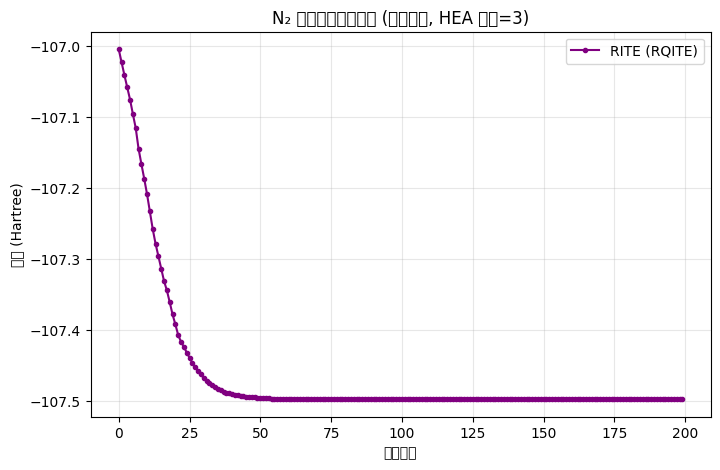

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(energies, label='RITE (RQITE)', color='purple', marker='o', markersize=3)
plt.title("N₂ 分子基态收敛曲线 (活性空间, HEA 深度=3)")
plt.xlabel("迭代步数")
plt.ylabel("能量 (Hartree)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### 2.6 算法性能讨论
在 $N₂$ 的 4 量子比特、16 参数的例子中， $m^2=256$，而 $Km=5×16=80$ ,实现了计算复杂度的降低。 在更大规模参数的情况下，RMITE降低计算复杂度的作用会更加明显。  

### 3. 总结
量子虚时演化（ITE）是制备基态的强有力工具，但其变分实现 VarQITE 受限于 QFIM 的 $O(m^2)$ 复杂度。  
利用 随机测量 可将 QFIM 估计复杂度降至 $O(Km)$ 。我们推导了两种估计器：  
**2‑design 估计器**：精确重构 QFIM，需要 $K$ 个随机 Clifford 酉门。  
**平均 CFIM 估计器**：更粗糙但下降速度极快，极端情况下 $K=1$ 即随机自然梯度。

**RQITESolver**（本示例） 选择后者，用多个随机酉下的 CFIM 替代 QFIM，在保持下降方向的同时大幅减少资源消耗。在 N₂ 分子的数值模拟中，RQITE 成功收敛到活性空间下的基态能量。

### 4. 参考文献
[1] Kolotouros, I., Joseph, D., & Narayanan, A.K. (2024). Accelerating quantum imaginary-time evolution with random measurements. Physical Review A.